# Active Lives London Prediction Model

This notebook loads `active_lives_with_clusters.csv` and:

- compares Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting;
- evaluates accuracy, precision, recall, Macro F1, cross-validation, and confusion matrices;
- reports tree-based feature importance;
- produces **Borough × Cluster segmentation tables**;
- produces **cluster-specific and borough-specific participation prediction summaries**;
- creates an **integrated cluster summary** directly from in-memory results.




In [1]:
# !pip install pandas numpy scikit-learn matplotlib joblib
from pathlib import Path
import time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

RANDOM_STATE = 42
DATA_PATH = Path("active_lives_with_clusters.csv")
OUTPUT_DIR = Path("prediction_model_outputs")

## 1. Load clustered data

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError("Run Notebook 1 first or update DATA_PATH.")
df = pd.read_csv(DATA_PATH, low_memory=False)
print(df.shape)
display(df.head())

(135497, 613)


,serial,mode,group,Quarter,MonthTwelve,wt_final,xStrata,LA_code,LA_2023,LA_Old,...,limfreti2,limfreti3,limfreti4,limfreti5,limfreti6,limfreti7,limfreti8,Age_4Band,Activity_Level,Cluster
0,1.511900e+14,CAWI,NaN,Y1Q1: Nov 2015-Feb 2016,Mid-Dec to Mid Jan,0.727690,9.0,8.0,E09000002 Barking and Dagenham,BARKING AND DAGENHAM LONDON BORO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25–44,Active,0
1,1.511900e+14,PAPER,NaN,Y1Q1: Nov 2015-Feb 2016,Mid-Dec to Mid Jan,1.120481,9.0,8.0,E09000002 Barking and Dagenham,BARKING AND DAGENHAM LONDON BORO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Active,0
2,1.511900e+14,PAPER,NaN,Y1Q1: Nov 2015-Feb 2016,Mid-Jan to Mid-Feb,0.708328,9.0,8.0,E09000002 Barking and Dagenham,BARKING AND DAGENHAM LONDON BORO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25–44,Fairly Active,2
3,1.511900e+14,CAWI,NaN,Y1Q1: Nov 2015-Feb 2016,Mid-Dec to Mid Jan,1.165601,9.0,8.0,E09000002 Barking and Dagenham,BARKING AND DAGENHAM LONDON BORO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45–64,Inactive,3
4,1.511900e+14,CAWI,NaN,Y1Q1: Nov 2015-Feb 2016,Mid Nov to Mid Dec,4.191322,9.0,8.0,E09000002 Barking and Dagenham,BARKING AND DAGENHAM LONDON BORO,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45–64,Inactive,3


## 2. Prepare modelling sample

In [3]:
features = ["Age_4Band","Gend3","Eth7","Educ6","NSSEC5","Disab3","borough","Cluster"]
target = "Activity_Level"

missing = [x for x in features + [target] if x not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

model_df = df[features + [target]].dropna(subset=[target]).copy()

# Important compatibility fix: use object + np.nan, not pandas StringDtype + pd.NA.
for col in features:
    model_df[col] = model_df[col].astype(object)
    model_df[col] = model_df[col].where(pd.notna(model_df[col]), np.nan)

model_df[target] = model_df[target].astype(str)
display(model_df.head())
display(model_df[target].value_counts(normalize=True))

,Age_4Band,Gend3,Eth7,Educ6,NSSEC5,Disab3,borough,Cluster,Activity_Level
0,25–44,Female,Other ethnic group,Level 4 or above,NS SEC 3-5: Middle social groups,No disability,Barking and Dagenham,0,Active
1,NaN,Female,Black,Level 4 or above,NaN,Non-limiting disability,Barking and Dagenham,0,Active
2,25–44,Male,South Asian,Level 4 or above,NS SEC 1-2: Higher social groups,No disability,Barking and Dagenham,2,Fairly Active
3,45–64,Male,White British,Level 2 and equivalents,NS SEC 3-5: Middle social groups,No disability,Barking and Dagenham,3,Inactive
4,45–64,Male,South Asian,Another type of qualification,NS SEC 3-5: Middle social groups,No disability,Barking and Dagenham,3,Inactive


Activity_Level
Active           0.665136
Inactive         0.223916
Fairly Active    0.110947
Name: proportion, dtype: float64

## 3. Train/test split

In [4]:
X = model_df[features]
y = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y,
    random_state=RANDOM_STATE
)
print(len(X_train), len(X_test))

108397 27100


## 4. Preprocessing

In [5]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False, dtype=np.float32)

preprocessor = ColumnTransformer([
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(
            strategy="constant", fill_value="Missing", missing_values=np.nan
        )),
        ("onehot", encoder)
    ]), features)
], remainder="drop", verbose_feature_names_out=False)

## 5. Models

In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1500, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=15, min_samples_split=20, min_samples_leaf=10,
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_split=10,
        min_samples_leaf=5, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=3,
        min_samples_split=20, min_samples_leaf=10,
        subsample=0.8, random_state=RANDOM_STATE
    )
}
pipelines = {
    name: Pipeline([("preprocessor", clone(preprocessor)), ("model", model)])
    for name, model in models.items()
}

## 6. Evaluation

In [7]:
scoring = {
    "accuracy":"accuracy",
    "precision_macro":"precision_macro",
    "recall_macro":"recall_macro",
    "f1_macro":"f1_macro"
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(name, pipe):
    start = time.time()
    fitted = clone(pipe).fit(X_train, y_train)
    train_pred = fitted.predict(X_train)
    test_pred = fitted.predict(X_test)

    cv_result = cross_validate(
        clone(pipe), X_train, y_train,
        scoring=scoring, cv=cv,
        n_jobs=1 if name == "Gradient Boosting" else -1,
        error_score="raise"
    )

    row = {
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Test Precision Macro": precision_score(y_test, test_pred, average="macro", zero_division=0),
        "Test Recall Macro": recall_score(y_test, test_pred, average="macro", zero_division=0),
        "Test F1 Macro": f1_score(y_test, test_pred, average="macro", zero_division=0),
        "CV Accuracy": cv_result["test_accuracy"].mean(),
        "CV Accuracy SD": cv_result["test_accuracy"].std(),
        "CV F1 Macro": cv_result["test_f1_macro"].mean(),
        "CV F1 SD": cv_result["test_f1_macro"].std(),
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Train F1 Macro": f1_score(y_train, train_pred, average="macro", zero_division=0),
        "Runtime Minutes": (time.time()-start)/60
    }
    row["Train–CV Accuracy Gap"] = row["Train Accuracy"] - row["CV Accuracy"]
    return row, fitted, test_pred

## 7. Run all models

In [8]:
results, fitted_models, predictions = [], {}, {}

for name, pipe in pipelines.items():
    print(f"\nEvaluating {name}")
    row, fitted, pred = evaluate(name, pipe)
    results.append(row)
    fitted_models[name] = fitted
    predictions[name] = pred
    print(row)

results_df = pd.DataFrame(results).sort_values(
    ["CV F1 Macro","Test F1 Macro","CV Accuracy"], ascending=False
).reset_index(drop=True)
display(results_df)


Evaluating Logistic Regression
{'Model': 'Logistic Regression', 'Test Accuracy': 0.5360147601476015, 'Test Precision Macro': 0.43518450859658536, 'Test Recall Macro': 0.45239459816347855, 'Test F1 Macro': 0.4309347779205496, 'CV Accuracy': 0.534535027520809, 'CV Accuracy SD': 0.006716198778911818, 'CV F1 Macro': 0.4273864198090392, 'CV F1 SD': 0.005338630712048581, 'Train Accuracy': 0.5355314261464801, 'Train F1 Macro': 0.4288828505643809, 'Runtime Minutes': 0.07750711838404338, 'Train–CV Accuracy Gap': 0.0009963986256711355}

Evaluating Decision Tree
{'Model': 'Decision Tree', 'Test Accuracy': 0.47974169741697414, 'Test Precision Macro': 0.42527521235629856, 'Test Recall Macro': 0.4350388856507628, 'Test F1 Macro': 0.40404215923118675, 'CV Accuracy': 0.4844690603878224, 'CV Accuracy SD': 0.009913727380924206, 'CV F1 Macro': 0.4029685345954455, 'CV F1 SD': 0.003947734232552512, 'Train Accuracy': 0.5124311558437964, 'Train F1 Macro': 0.4430956859998115, 'Runtime Minutes': 0.05986474752

,Model,Test Accuracy,Test Precision Macro,Test Recall Macro,Test F1 Macro,CV Accuracy,CV Accuracy SD,CV F1 Macro,CV F1 SD,Train Accuracy,Train F1 Macro,Runtime Minutes,Train–CV Accuracy Gap
0,Logistic Regression,0.536015,0.435185,0.452395,0.430935,0.534535,0.006716,0.427386,0.005339,0.535531,0.428883,0.077507,0.000996
1,Random Forest,0.540295,0.430550,0.450798,0.428024,0.544028,0.006924,0.426138,0.004606,0.576935,0.480779,0.228745,0.032907
2,Decision Tree,0.479742,0.425275,0.435039,0.404042,0.484469,0.009914,0.402969,0.003948,0.512431,0.443096,0.059865,0.027962
3,Gradient Boosting,0.679299,0.407770,0.383653,0.362935,0.680701,0.001934,0.363298,0.002945,0.681615,0.364834,2.265182,0.000913


## 8. Classification reports and confusion matrices


 Logistic Regression
               precision    recall  f1-score   support

       Active     0.7801    0.5865    0.6696     18025
Fairly Active     0.1359    0.2358    0.1724      3007
     Inactive     0.3895    0.5349    0.4508      6068

     accuracy                         0.5360     27100
    macro avg     0.4352    0.4524    0.4309     27100
 weighted avg     0.6212    0.5360    0.5654     27100



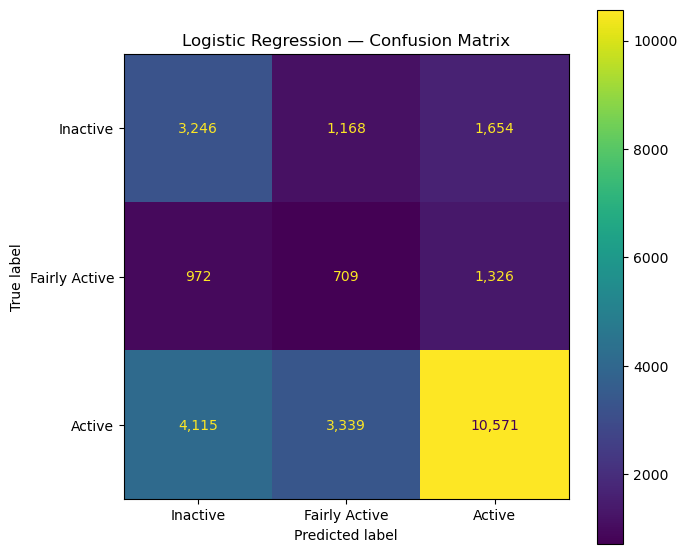


 Decision Tree
               precision    recall  f1-score   support

       Active     0.7855    0.5017    0.6123     18025
Fairly Active     0.1247    0.2996    0.1761      3007
     Inactive     0.3656    0.5038    0.4237      6068

     accuracy                         0.4797     27100
    macro avg     0.4253    0.4350    0.4040     27100
 weighted avg     0.6182    0.4797    0.5217     27100



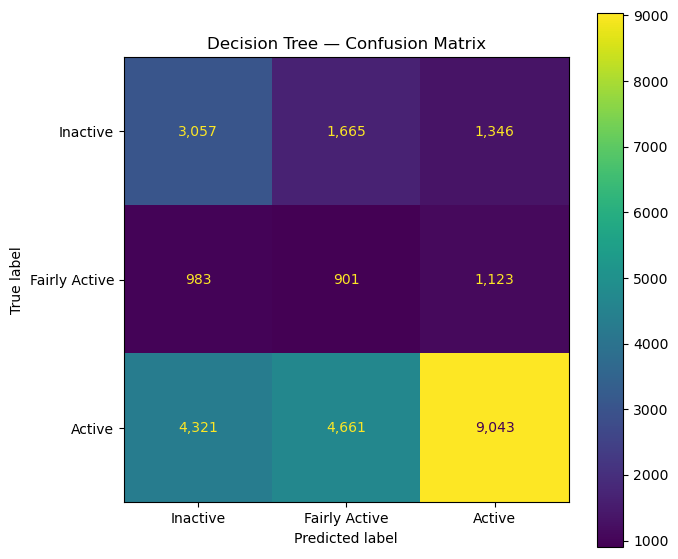


 Random Forest
               precision    recall  f1-score   support

       Active     0.7786    0.5883    0.6702     18025
Fairly Active     0.1350    0.1955    0.1598      3007
     Inactive     0.3780    0.5686    0.4541      6068

     accuracy                         0.5403     27100
    macro avg     0.4305    0.4508    0.4280     27100
 weighted avg     0.6175    0.5403    0.5652     27100



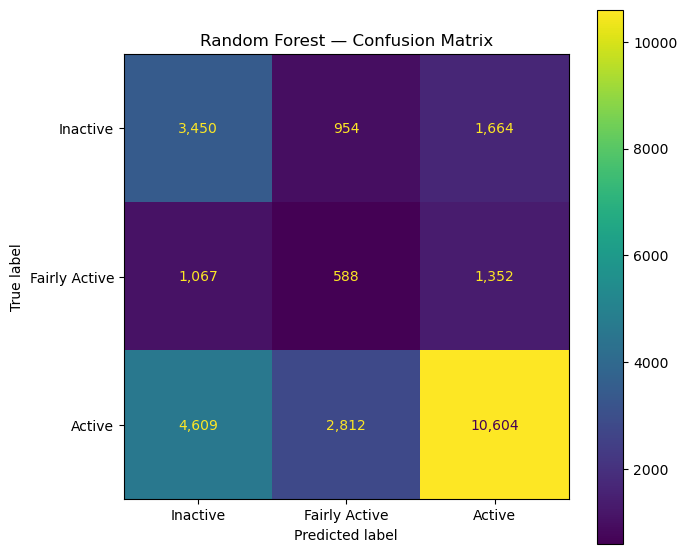


 Gradient Boosting
               precision    recall  f1-score   support

       Active     0.6927    0.9555    0.8031     18025
Fairly Active     0.0000    0.0000    0.0000      3007
     Inactive     0.5306    0.1955    0.2857      6068

     accuracy                         0.6793     27100
    macro avg     0.4078    0.3837    0.3629     27100
 weighted avg     0.5795    0.6793    0.5981     27100



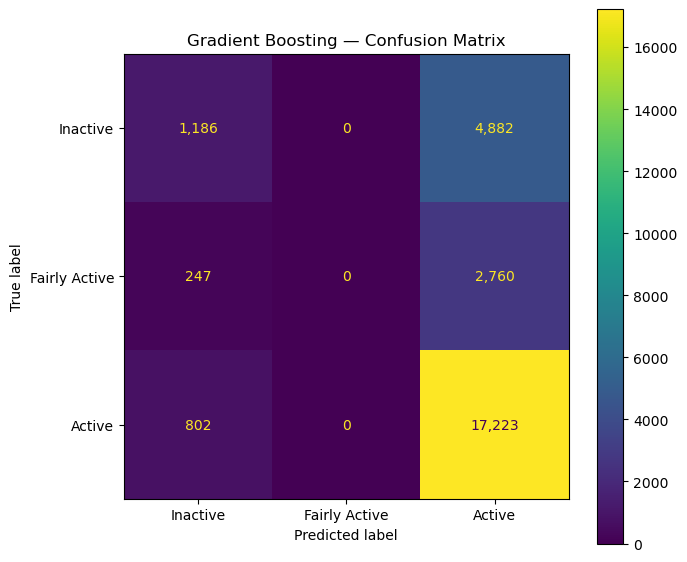

In [9]:
classes = ["Inactive","Fairly Active","Active"]

for name, pred in predictions.items():
    print("\n", "="*70, "\n", name)
    print(classification_report(y_test, pred, digits=4, zero_division=0))

    fig, ax = plt.subplots(figsize=(7,6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, labels=classes, values_format=",d", ax=ax
    )
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

## 9. Model comparison plots

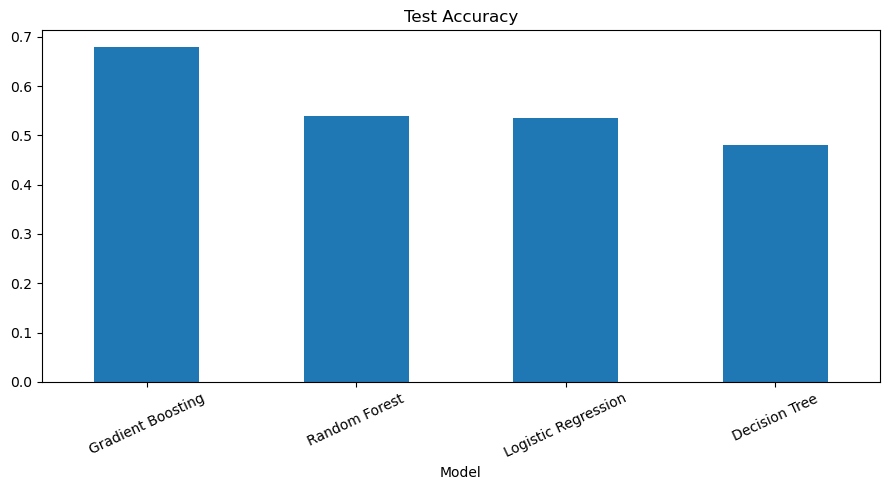

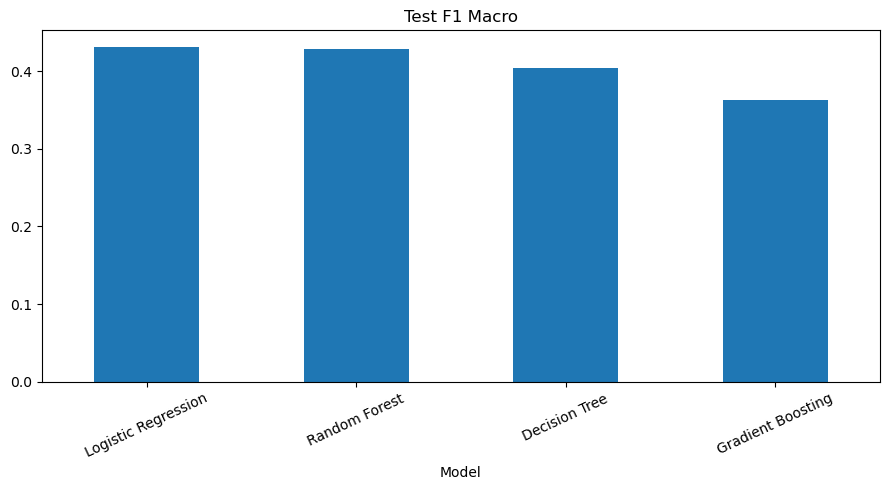

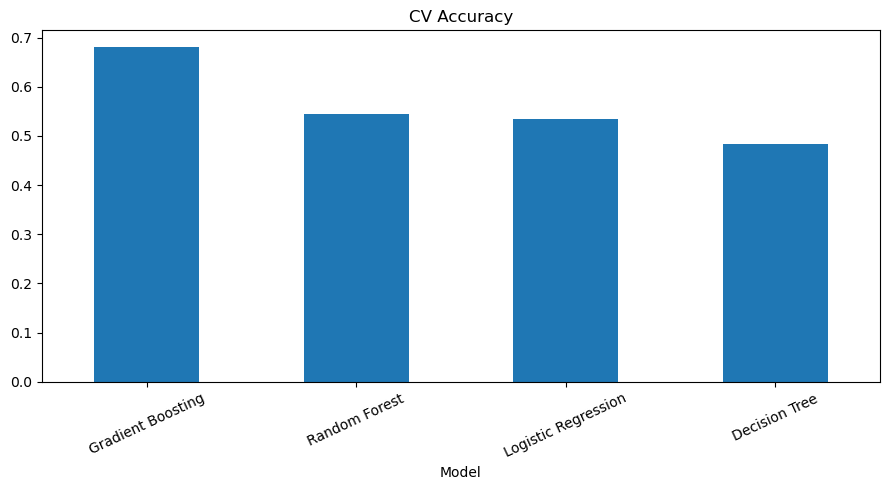

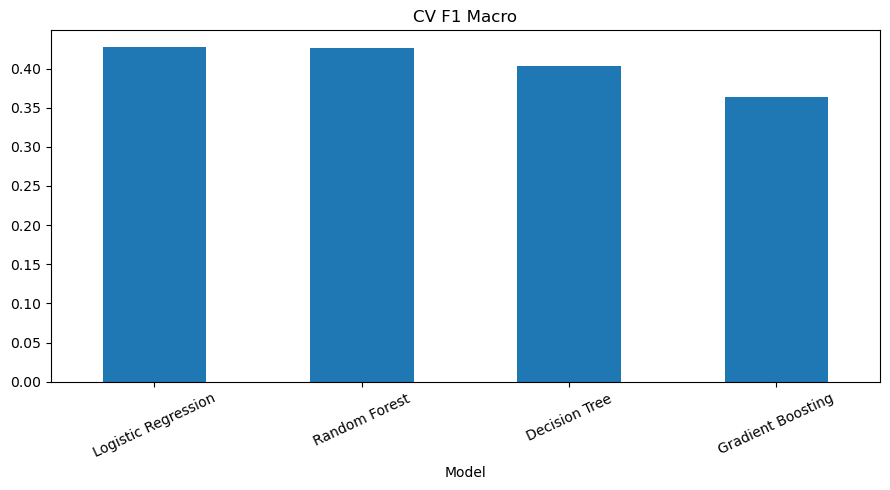

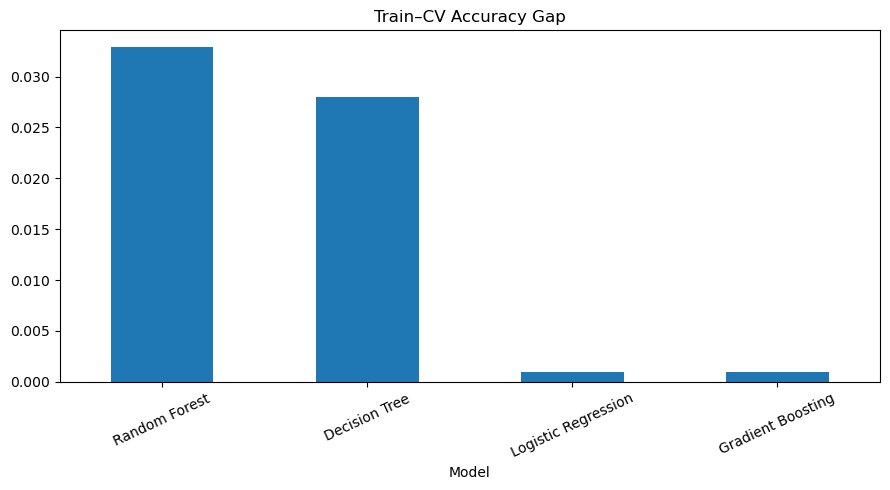

In [10]:
plot_df = results_df.set_index("Model")
for metric in ["Test Accuracy","Test F1 Macro","CV Accuracy","CV F1 Macro","Train–CV Accuracy Gap"]:
    plot_df[metric].sort_values(ascending=False).plot(kind="bar", figsize=(9,5))
    plt.title(metric)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

## 10. Tree-based feature importance

In [11]:
def grouped_importance(pipe):
    model = pipe.named_steps["model"]
    if not hasattr(model, "feature_importances_"):
        return None
    names = pipe.named_steps["preprocessor"].get_feature_names_out()
    detail = pd.DataFrame({"Encoded Feature": names, "Importance": model.feature_importances_})
    ordered = sorted(features, key=len, reverse=True)
    def source(n):
        for f in ordered:
            if n == f or n.startswith(f + "_"):
                return f
        return "Other"
    detail["Original Feature"] = detail["Encoded Feature"].map(source)
    return detail.groupby("Original Feature", as_index=False)["Importance"].sum().sort_values("Importance", ascending=False)

for name in ["Decision Tree","Random Forest","Gradient Boosting"]:
    imp = grouped_importance(fitted_models[name])
    print(name)
    display(imp)

Decision Tree


,Original Feature,Importance
6,NSSEC5,0.232240
7,borough,0.206669
3,Educ6,0.150588
4,Eth7,0.146987
2,Disab3,0.114127
0,Age_4Band,0.078419
1,Cluster,0.042748
5,Gend3,0.028221


Random Forest


,Original Feature,Importance
7,borough,0.215624
3,Educ6,0.189888
6,NSSEC5,0.172299
4,Eth7,0.151655
2,Disab3,0.120411
0,Age_4Band,0.076987
1,Cluster,0.041332
5,Gend3,0.031804


Gradient Boosting


,Original Feature,Importance
6,NSSEC5,0.265330
3,Educ6,0.257522
4,Eth7,0.180571
2,Disab3,0.155906
0,Age_4Band,0.088990
7,borough,0.032373
5,Gend3,0.012674
1,Cluster,0.006633


## 11. Borough segmentation

These tables show how the K-Modes population segments are distributed across London boroughs.

- **Counts** show the number of respondents in each Borough × Cluster combination.
- **Row percentages** show the cluster composition within each borough; each borough row sums to approximately 100%.


In [12]:
# Borough × Cluster counts
borough_cluster_counts = pd.crosstab(
    df["borough"],
    df["Cluster"],
    margins=True,
    margins_name="Total"
)

print("Borough × Cluster counts")
display(borough_cluster_counts)

# Borough × Cluster row percentages (excluding totals)
borough_cluster_percentages = (
    pd.crosstab(
        df["borough"],
        df["Cluster"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

# Add a check column; values should be approximately 100.
borough_cluster_percentages["Row Total (%)"] = (
    borough_cluster_percentages.sum(axis=1).round(2)
)

print("Cluster composition within each borough (%)")
display(borough_cluster_percentages)


Borough × Cluster counts


Cluster,0,1,2,3,Total
borough,,,,,
Barking and Dagenham,2012,1069,1174,713,4968
Barnet,1816,1321,1330,490,4957
Bexley,1426,969,930,634,3959
Brent,1575,926,1114,438,4053
Bromley,1361,1142,980,462,3945
Camden,1627,1046,1059,288,4020
Croydon,1482,1059,992,468,4001
Ealing,1452,1115,1048,383,3998
Enfield,1854,1405,1122,602,4983


Cluster composition within each borough (%)


Cluster,0,1,2,3,Row Total (%)
borough,,,,,
Barking and Dagenham,40.50,21.52,23.63,14.35,100.00
Barnet,36.64,26.65,26.83,9.89,100.01
Bexley,36.02,24.48,23.49,16.01,100.00
Brent,38.86,22.85,27.49,10.81,100.01
Bromley,34.50,28.95,24.84,11.71,100.00
Camden,40.47,26.02,26.34,7.16,99.99
Croydon,37.04,26.47,24.79,11.70,100.00
Ealing,36.32,27.89,26.21,9.58,100.00
Enfield,37.21,28.20,22.52,12.08,100.01


## 12. Cluster-specific participation forecasts

For preliminary reporting, Random Forest is used as the balanced candidate model identified in the comparison.

Two complementary summaries are produced:

1. **Predicted-class percentages**: the percentage assigned to each activity class within each cluster.
2. **Mean predicted probabilities**: the model's average probability for each activity class within each cluster.

These are model-based estimates for the held-out test sample, not future time-series forecasts.


In [13]:
# Selected as the final model based on balanced multi-class performance
# and highest accuracy among models that predicted all activity classes.
# Select the model used for the cluster-level preliminary forecast.
FORECAST_MODEL = "Random Forest"

if FORECAST_MODEL not in fitted_models:
    raise KeyError(f"{FORECAST_MODEL!r} is not available in fitted_models.")

forecast_model = fitted_models[FORECAST_MODEL]
forecast_predictions = predictions[FORECAST_MODEL]

# Preserve the test-row indices so clusters, actual outcomes, and predictions align.
cluster_forecast_df = pd.DataFrame({
    "Borough": X_test["borough"].to_numpy(),
    "Cluster": X_test["Cluster"].to_numpy(),
    "Actual Activity Level": y_test.to_numpy(),
    "Predicted Activity Level": forecast_predictions
})

display(cluster_forecast_df.head())


,Borough,Cluster,Actual Activity Level,Predicted Activity Level
0,Kensington and Chelsea,1,Active,Active
1,Kensington and Chelsea,1,Active,Active
2,Sutton,0,Active,Inactive
3,Barnet,0,Active,Active
4,Redbridge,1,Active,Inactive


In [14]:
# Predicted activity-class distribution within each cluster (%)
cluster_predicted_percentages = (
    pd.crosstab(
        cluster_forecast_df["Cluster"],
        cluster_forecast_df["Predicted Activity Level"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

# Ensure all expected outcome columns appear even when a model predicts none
# of a particular class.
activity_classes = ["Active", "Fairly Active", "Inactive"]
cluster_predicted_percentages = cluster_predicted_percentages.reindex(
    columns=activity_classes,
    fill_value=0
)
cluster_predicted_percentages["Row Total (%)"] = (
    cluster_predicted_percentages.sum(axis=1).round(2)
)

print(f"Predicted activity distribution by cluster — {FORECAST_MODEL} (%)")
display(cluster_predicted_percentages)


Predicted activity distribution by cluster — Random Forest (%)


Predicted Activity Level,Active,Fairly Active,Inactive,Row Total (%)
Cluster,,,,
0,44.62,19.60,35.77,99.99
1,62.53,15.25,22.22,100.00
2,57.50,11.17,31.33,100.00
3,20.00,17.69,62.31,100.00


In [15]:
# Mean predicted probability for each activity class within each cluster
if not hasattr(forecast_model, "predict_proba"):
    print(f"{FORECAST_MODEL} does not support predict_proba().")
    cluster_mean_probabilities = None
else:
    probability_values = forecast_model.predict_proba(X_test)
    model_classes = list(forecast_model.named_steps["model"].classes_)

    probability_df = pd.DataFrame(
        probability_values,
        columns=model_classes
    )
    probability_df["Cluster"] = X_test["Cluster"].to_numpy()

    cluster_mean_probabilities = (
        probability_df.groupby("Cluster")[model_classes]
        .mean()
        .mul(100)
        .round(2)
        .reindex(columns=activity_classes, fill_value=0)
    )
    cluster_mean_probabilities["Probability Total (%)"] = (
        cluster_mean_probabilities.sum(axis=1).round(2)
    )

    print(f"Mean predicted activity probabilities by cluster — {FORECAST_MODEL} (%)")
    display(cluster_mean_probabilities)


Mean predicted activity probabilities by cluster — Random Forest (%)


,Active,Fairly Active,Inactive,Probability Total (%)
Cluster,,,,
0,34.17,33.33,32.50,100.0
1,39.40,33.04,27.56,100.0
2,37.99,31.02,30.99,100.0
3,29.47,31.48,39.05,100.0


In [16]:
# Observed test-sample activity distribution by cluster for comparison
cluster_actual_percentages = (
    pd.crosstab(
        cluster_forecast_df["Cluster"],
        cluster_forecast_df["Actual Activity Level"],
        normalize="index"
    )
    .mul(100)
    .round(2)
    .reindex(columns=activity_classes, fill_value=0)
)
cluster_actual_percentages["Row Total (%)"] = (
    cluster_actual_percentages.sum(axis=1).round(2)
)

print("Observed activity distribution by cluster in the test sample (%)")
display(cluster_actual_percentages)


Observed activity distribution by cluster in the test sample (%)


Actual Activity Level,Active,Fairly Active,Inactive,Row Total (%)
Cluster,,,,
0,64.17,12.11,23.72,100.0
1,70.88,10.96,18.16,100.0
2,68.51,9.96,21.53,100.0
3,58.73,10.54,30.73,100.0


## 13. Borough-level participation prediction summaries

The model still predicts the activity level of each individual respondent. This section then groups those individual predictions by borough to estimate the percentage predicted to be Active, Fairly Active, or Inactive in each borough.

It also provides a Borough × Cluster summary, allowing predicted activity patterns to be compared within demographic clusters across locations. These are held-out test-sample prediction summaries, not future time-series forecasts.


In [17]:
# Predicted activity-class distribution within each borough (%)
borough_predicted_percentages = (
    pd.crosstab(
        cluster_forecast_df["Borough"],
        cluster_forecast_df["Predicted Activity Level"],
        normalize="index"
    )
    .mul(100)
    .round(2)
    .reindex(columns=activity_classes, fill_value=0)
)
borough_predicted_percentages["Row Total (%)"] = (
    borough_predicted_percentages.sum(axis=1).round(2)
)

print(f"Predicted activity distribution by borough — {FORECAST_MODEL} (%)")
display(borough_predicted_percentages)


# Observed test-sample activity distribution by borough for comparison
borough_actual_percentages = (
    pd.crosstab(
        cluster_forecast_df["Borough"],
        cluster_forecast_df["Actual Activity Level"],
        normalize="index"
    )
    .mul(100)
    .round(2)
    .reindex(columns=activity_classes, fill_value=0)
)
borough_actual_percentages["Row Total (%)"] = (
    borough_actual_percentages.sum(axis=1).round(2)
)

print("Observed activity distribution by borough in the test sample (%)")
display(borough_actual_percentages)


Predicted activity distribution by borough — Random Forest (%)


Predicted Activity Level,Active,Fairly Active,Inactive,Row Total (%)
Borough,,,,
Barking and Dagenham,15.85,20.73,63.41,99.99
Barnet,51.57,18.60,29.83,100.00
Bexley,42.52,20.57,36.91,100.00
Brent,31.95,22.64,45.41,100.00
Bromley,60.41,13.20,26.40,100.01
Camden,56.16,12.56,31.28,100.00
Croydon,48.23,22.28,29.49,100.00
Ealing,46.49,17.84,35.68,100.01
Enfield,42.17,15.85,41.97,99.99


Observed activity distribution by borough in the test sample (%)


Actual Activity Level,Active,Fairly Active,Inactive,Row Total (%)
Borough,,,,
Barking and Dagenham,53.56,13.82,32.62,100.00
Barnet,66.03,11.22,22.75,100.00
Bexley,64.71,10.97,24.31,99.99
Brent,59.49,13.83,26.68,100.00
Bromley,66.62,11.55,21.83,100.00
Camden,68.23,10.47,21.31,100.01
Croydon,68.99,10.51,20.51,100.01
Ealing,62.70,12.57,24.73,100.00
Enfield,60.32,12.36,27.32,100.00


In [18]:
# Predicted activity distribution within each Borough × Cluster group (%)
borough_cluster_predicted_percentages = (
    pd.crosstab(
        [
            cluster_forecast_df["Borough"],
            cluster_forecast_df["Cluster"]
        ],
        cluster_forecast_df["Predicted Activity Level"],
        normalize="index"
    )
    .mul(100)
    .round(2)
    .reindex(columns=activity_classes, fill_value=0)
)
borough_cluster_predicted_percentages["Row Total (%)"] = (
    borough_cluster_predicted_percentages.sum(axis=1).round(2)
)

print(f"Predicted activity distribution by Borough × Cluster — {FORECAST_MODEL} (%)")
display(borough_cluster_predicted_percentages)


Predicted activity distribution by Borough × Cluster — Random Forest (%)


Predicted Activity Level      Active  Fairly Active  Inactive  Row Total (%)
Borough              Cluster                                                
Barking and Dagenham 0         12.84          20.74     66.42         100.00
                     1         19.42          31.07     49.51         100.00
                     2         19.59          17.14     63.27         100.00
                     3         12.50          10.94     76.56         100.00
Barnet               0         44.87          20.51     34.62         100.00
...                              ...            ...       ...            ...
Wandsworth           3         17.07           7.32     75.61         100.00
Westminster          0         47.74          21.29     30.97         100.00
                     1         67.15          12.56     20.29         100.00
                     2         64.04           4.82     31.14         100.00
                     3         24.44           4.44     71.11          99.99

[128 rows x 4 columns]

## 14. Integrated cluster profile summary

This table combines each cluster's modal demographic characteristics with its observed and model-predicted activity distributions. It is calculated directly from the loaded data and the in-memory forecast tables, so it does not depend on intermediate CSV files.


In [19]:
# Demographic variables used to describe each cluster
profile_features = [
    "Age_4Band", "Gend3", "Eth7",
    "Educ6", "NSSEC5", "Disab3"
]

def first_mode(series):
    """Return the first non-missing mode, or NaN when no mode is available."""
    modes = series.dropna().mode()
    return modes.iloc[0] if not modes.empty else np.nan

# Calculate cluster modes directly from the loaded clustered dataset.
cluster_modes = (
    df.groupby("Cluster")[profile_features]
      .agg(first_mode)
      .sort_index()
)

# Remove total/check columns before combining the activity tables.
actual_for_summary = cluster_actual_percentages.drop(
    columns=["Row Total (%)"], errors="ignore"
)
predicted_for_summary = cluster_predicted_percentages.drop(
    columns=["Row Total (%)"], errors="ignore"
)

# Make sure every expected activity class is present and consistently ordered.
actual_for_summary = actual_for_summary.reindex(
    columns=activity_classes, fill_value=0
)
predicted_for_summary = predicted_for_summary.reindex(
    columns=activity_classes, fill_value=0
)

# Use all clusters appearing in the demographic profile table.
cluster_index = cluster_modes.index

cluster_summary = cluster_modes.reindex(cluster_index).reset_index()

cluster_summary["Observed Active (%)"] = (
    actual_for_summary.reindex(cluster_index)["Active"].to_numpy()
)
cluster_summary["Observed Fairly Active (%)"] = (
    actual_for_summary.reindex(cluster_index)["Fairly Active"].to_numpy()
)
cluster_summary["Observed Inactive (%)"] = (
    actual_for_summary.reindex(cluster_index)["Inactive"].to_numpy()
)

cluster_summary["Predicted Active (%)"] = (
    predicted_for_summary.reindex(cluster_index)["Active"].to_numpy()
)
cluster_summary["Predicted Fairly Active (%)"] = (
    predicted_for_summary.reindex(cluster_index)["Fairly Active"].to_numpy()
)
cluster_summary["Predicted Inactive (%)"] = (
    predicted_for_summary.reindex(cluster_index)["Inactive"].to_numpy()
)

percentage_columns = [
    col for col in cluster_summary.columns if col.endswith("(%)")
]
cluster_summary[percentage_columns] = (
    cluster_summary[percentage_columns].round(1)
)

print("Integrated cluster profile summary")
display(cluster_summary)


Integrated cluster profile summary


,Cluster,Age_4Band,Gend3,Eth7,Educ6,NSSEC5,Disab3,Observed Active (%),Observed Fairly Active (%),Observed Inactive (%),Predicted Active (%),Predicted Fairly Active (%),Predicted Inactive (%)
0,0,25–44,Female,White British,Level 4 or above,NS SEC 1-2: Higher social groups,No disability,64.2,12.1,23.7,44.6,19.6,35.8
1,1,45–64,Female,White British,Level 4 or above,NS SEC 1-2: Higher social groups,No disability,70.9,11.0,18.2,62.5,15.2,22.2
2,2,25–44,Male,White British,Level 4 or above,NS SEC 1-2: Higher social groups,No disability,68.5,10.0,21.5,57.5,11.2,31.3
3,3,45–64,Male,White British,Level 2 and equivalents,NS SEC 3-5: Middle social groups,No disability,58.7,10.5,30.7,20.0,17.7,62.3


## 14. Save results, analytical tables, and models


In [20]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Model-comparison outputs
results_df.to_csv(
    OUTPUT_DIR / "model_comparison_results.csv",
    index=False
)

pred_df = pd.DataFrame({
    "Cluster": X_test["Cluster"].to_numpy(),
    "Actual": y_test.to_numpy()
})
for name, pred in predictions.items():
    pred_df["Predicted_" + name.lower().replace(" ", "_")] = pred

pred_df.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False
)

# Borough segmentation outputs
borough_cluster_counts.to_csv(
    OUTPUT_DIR / "borough_cluster_counts.csv"
)
borough_cluster_percentages.to_csv(
    OUTPUT_DIR / "borough_cluster_percentages.csv"
)

# Cluster-specific participation outputs
cluster_forecast_df.to_csv(
    OUTPUT_DIR / "cluster_forecast_test_rows.csv",
    index=False
)
cluster_predicted_percentages.to_csv(
    OUTPUT_DIR / "cluster_predicted_activity_percentages.csv"
)
cluster_actual_percentages.to_csv(
    OUTPUT_DIR / "cluster_actual_activity_percentages.csv"
)

if cluster_mean_probabilities is not None:
    cluster_mean_probabilities.to_csv(
        OUTPUT_DIR / "cluster_mean_predicted_probabilities.csv"
    )

# Borough-level participation prediction outputs
borough_predicted_percentages.to_csv(
    OUTPUT_DIR / "borough_predicted_activity_percentages.csv"
)
borough_actual_percentages.to_csv(
    OUTPUT_DIR / "borough_actual_activity_percentages.csv"
)
borough_cluster_predicted_percentages.to_csv(
    OUTPUT_DIR / "borough_cluster_predicted_activity_percentages.csv"
)

# Integrated cluster profile output
cluster_modes.to_csv(
    OUTPUT_DIR / "cluster_modes_from_loaded_data.csv"
)
cluster_summary.to_csv(
    OUTPUT_DIR / "cluster_summary.csv",
    index=False
)

# Save fitted pipelines
for name, fitted in fitted_models.items():
    model_filename = name.lower().replace(" ", "_") + "_pipeline.joblib"
    joblib.dump(fitted, OUTPUT_DIR / model_filename)

print(f"Saved all outputs to: {OUTPUT_DIR.resolve()}")
print("\nRefined outputs include:")
print("- model_comparison_results.csv")
print("- borough_cluster_counts.csv")
print("- borough_cluster_percentages.csv")
print("- cluster_predicted_activity_percentages.csv")
print("- cluster_mean_predicted_probabilities.csv")
print("- cluster_actual_activity_percentages.csv")
print("- borough_predicted_activity_percentages.csv")
print("- borough_actual_activity_percentages.csv")
print("- borough_cluster_predicted_activity_percentages.csv")
print("- cluster_modes_from_loaded_data.csv")
print("- cluster_summary.csv")


Saved all outputs to: /Users/sanyakapoor/Downloads/FINAL NOTEBOOK/prediction_model_outputs

Refined outputs include:
- model_comparison_results.csv
- borough_cluster_counts.csv
- borough_cluster_percentages.csv
- cluster_predicted_activity_percentages.csv
- cluster_mean_predicted_probabilities.csv
- cluster_actual_activity_percentages.csv
- borough_predicted_activity_percentages.csv
- borough_actual_activity_percentages.csv
- borough_cluster_predicted_activity_percentages.csv
- cluster_modes_from_loaded_data.csv
- cluster_summary.csv
